In [1]:
import pandas as pd
import numpy as np
import optimization as opt
import matplotlib.pyplot as plt
import geopandas as gpd
import pydeck as pdk
pdk.settings.rendering = "iframe"

import optimization_plots
import importlib

importlib.reload(optimization_plots)
importlib.reload(opt)


hexagons = gpd.read_file('hexagon_grid.shp').to_crs(epsg=4326)
germany_extent = [4, 17, 46, 56]

ERROR 1: PROJ: proj_create_from_database: Open of /home/konni/anaconda3/envs/velux_opt/share/proj failed


# Management Options

- no-mgmt,
- low-structure = Kahlschlag bzw. Schirmschlag je nachdem ob Laubholz- oder Nadelholz-dominiert
- medium-structure = Femelschlagverfahren (group selection)
- high-structure = Plenter (single tree selection)

Original data has 23232000 rows.

In [193]:
# reading takes 1.5min
iland_cluster6_chunks = pd.read_csv('cluster6_for_Konstantin_hexagon.csv.gz', chunksize=10000)
iland_cluster6 = pd.concat([chunk[(chunk['RCPScenario'] != 'historical') & (chunk['ClimateModel'] == 'ICHEC-EC-EARTH') & (chunk['Replicate'] == 'repl0')] for chunk in iland_cluster6_chunks])

# Optimize a dataframe with multiple GCs

In [194]:
ES = ['abovegroundCarbon', 'shannonIndex', 'evapotranspiration_mm', 'mean_soilwatercontent_mm', 'volumeHarvested']

In [195]:
iland_multiple_gc = iland_cluster6.copy()
iland_multiple_gc = iland_multiple_gc[iland_multiple_gc['decade'] == 8][['rid', 'Germany_id', 'RCPScenario', 'Management'] + ES]
iland_multiple_gc = iland_multiple_gc.set_index(['rid', 'Germany_id', 'RCPScenario', 'Management'])

In [197]:
# 1min for 12000 rids, using 1 climate model and 1 replicate
# TODO problem, with multiple replicates, and multiple models, this will take much longer. maybe webapp is not the best thing...

portfolios = iland_multiple_gc.groupby(['rid', 'Germany_id'], group_keys=False).apply(opt.prepare_and_optimize_gridcell)

In [229]:
importlib.reload(opt)
data_for_optimizer = iland_multiple_gc.groupby(['rid', 'Germany_id'], group_keys=False).apply(opt.prepare_for_optimization)

In [238]:
data_for_optimizer.to_csv('brandenburd_optimizer_data.csv')

# Optimization

In [ ]:
weights = [1.0, 0.0, 0.0, 0.0, 0.0]

In [2]:
data_for_optimizer = pd.read_csv('brandenburd_optimizer_data.csv').set_index(['ES', 'Germany_id', 'rid', 'RCPScenario'])

In [33]:
importlib.reload(opt)
optimized_data_original = data_for_optimizer.groupby(['rid', 'Germany_id'], group_keys=False).apply(lambda gc: opt.optimize_gridcell(gc, gc.name, es_weights=weights))

In [78]:
from joblib import Parallel, delayed

importlib.reload(opt)

groups = list(data_for_optimizer.groupby(['rid', 'Germany_id']))

def process_chunk(chunk):
    out = []
    for name, gc in chunk:
        df = opt.optimize_gridcell(gc, name, es_weights=weights)
        df = df.copy()
        df['rid'] = name[0]
        df['Germany_id'] = name[1]
        out.append(df)
    return out

chunk_size = 500  # tune this!
chunks = [groups[i:i+chunk_size] for i in range(0, len(groups), chunk_size)]

results = Parallel(n_jobs=-1)(
    delayed(process_chunk)(chunk) for chunk in chunks
)

optimized_data = pd.DataFrame([s for sublist in results for s in sublist]).set_index(['rid', 'Germany_id'])

In [79]:
mean_portfolios = optimized_data.groupby('Germany_id').apply(opt.compute_mean_portfolios)

In [80]:
final_data = mean_portfolios.reset_index().merge(
    hexagons,
    right_on="Germany_id",
    left_on="Germany_id"
)

final_data["lon"] = final_data.geometry.apply(lambda x: x.representative_point().x)
final_data["lat"] = final_data.geometry.apply(lambda x: x.representative_point().y)

In [81]:
optimization_plots.deck_plot(final_data)

{
  "initialViewState": {
    "latitude": 52.09672822222311,
    "longitude": 13.265655262010336,
    "zoom": 8
  },
  "layers": [
    {
      "@@type": "PolygonLayer",
      "autoHighlight": true,
      "data": [
        {
          "color": [
            255,
            165,
            0,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.405934609594869,
              52.246312027767544
            ],
            [
              11.401395002063317,
              52.261890094660906
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "high-structure",
          "value": 0.056201829620984474
        },
        {
          "color": [
            50,
            205,
            50,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.401395002063317,
              52.261890094660906
            ],
            [
              11.392457635042632,
              52.272298423987465
            ],
            [
              11.37942497471665,
              52.28093582335618
            ],
            [
              11.363185175349097,
              52.28721366827406
            ],
            [
              11.344844952429334,
              52.29070413398458
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "low-structure",
          "value": 0.16666666666666666
        },
        {
          "color": [
            0,
            100,
            0,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.344844952429334,
              52.29070413398458
            ],
            [
              11.333108771108122,
              52.29135476363166
            ],
            [
              11.332363832914963,
              52.246312027767544
            ]
          ],
          "slice": "medium-structure",
          "value": 0.025519958652102104
        },
        {
          "color": [
            128,
            0,
            128,
            160
          ],
          "name": "Portfolio",
          "polygon": [
            [
              11.332363832914963,
              52.246312027767544
            ],
            [
              11.333108771108122,
              52.29135476363166
            ],
            [
              11.316685234471302,
              52.290322316925355
            ],
            [
              11.301051256209371,
              52.287073556528085
            ],
            [
              11.286994147669954,
              52.28177208673069
            ],
            [
              11.275221810634829,
              52.27468488419518
            ],
            [
              11.266327088101505,
              52.266168853279865
            ],
            [
              11.260757909308923,
              52.256652852696455
            ],
            [
              11.258794732473595,
              52.246616098618695
            ],
            [
              11.26053642119722,
              52.23656403184013
            ],
            [
              11.265895265795598,
              52.227002864286426
            ],
            [
              11.274601400269699,
              52.218414086694324
            ],
            [
              11.286216392484684,
              52.211230221224675
            ],
            [
              11.300155323169195,
              52.20581304008345
            ],
            [
              11.31571624185881,
              52.

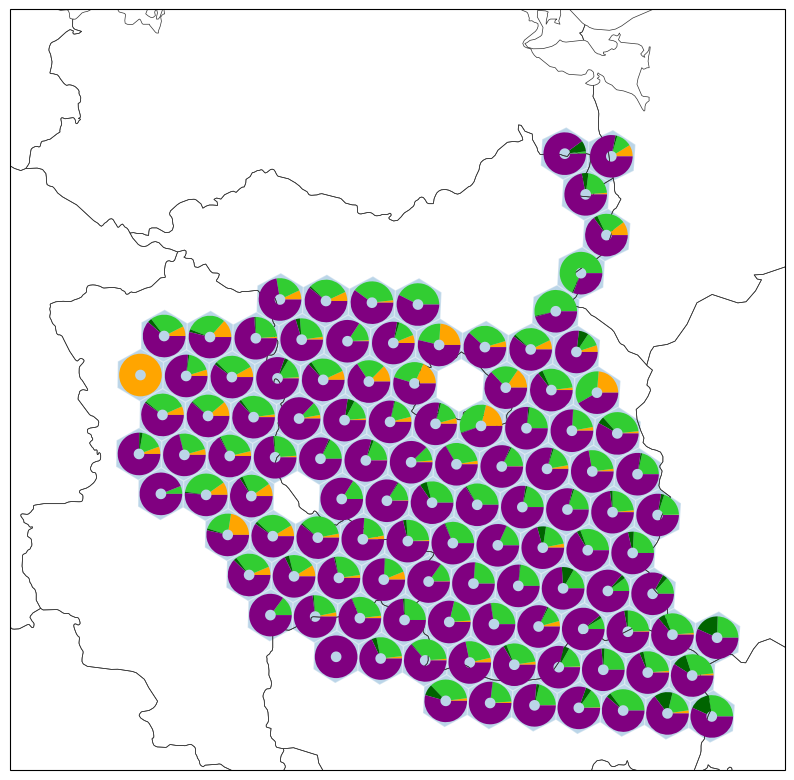

In [237]:
optimization_plots.plot_portfolios_on_hexagons(final_data)

# TODOs for Johannes

- base values --> even for decade == 1 the values differ.
  - obwohl, vllt fuer historical scenario?
- other ESs